# Batch-size sensitivity — R2 Q1

> **The question.** R2: *"How sensitive is the performance of Sven to changes in batch
> size, compared to alternative approaches?  Can you provide experimental results on the
> impact of varying batch sizes?"*

`rebuttal_batchsize_polynomial_scan`: $B \in \{8, 16, 32, 64, 128, 256\}$ on the random
polynomial ($N_\mathrm{train} = 10{,}000$, 20 epochs, 5 model seeds), Sven against the full
12-baseline suite.  **3,060 runs.**

Three things make this scan readable, and each needs saying out loud:

1. **Sven's rank is tied to $B$ by construction.**  The Jacobian $M \in \mathbb{R}^{B\times P}$
   has at most $B$ rows, so the update rank can never exceed the batch size.  This scan pins
   $k = B$ (`k_fraction = 1` throughout — there are **no** $k/B < 1$ arms here), which means
   the only truncation is `rtol`, and the rank the update *actually* used is recorded per run
   (`svd_summary.num_nonzero_svs_epoch`).  §3 plots it: that is the honest "$k/B$ fraction"
   for this scan.
2. **Equal epochs is not an equal budget.**  Every method runs 20 epochs, so at $B = 8$ that
   is 25,000 optimizer steps and at $B = 256$ it is 780 — a 32× difference in steps at
   constant examples.  §2 makes both axes explicit; a loss-vs-$B$ curve read as "bigger
   batches are better" is really reading "fewer, better-conditioned steps".
3. **L-BFGS runs at a pinned shape.**  Per decision O5 the L-BFGS grid is fixed at
   `max_iter = 3`, `history_size = 2` (5 learning rates), cutting 810 runs to 150.  It is
   also the method this scan destroys: it diverges on 23 of 25 runs at $B = 8$ and has **no
   eligible configuration below $B = 64$**, which is why the field size changes with $B$.

Conventions as everywhere: selection = eligible → fewest diverged → seed-mean final
**validation** loss, per batch size; test loss is an outcome; diverged = failed and is
counted; bands are ± 1 std over seeds.  Wall-clock numbers are the scan's own clock (many
processes per GPU, no `_timing` pass for this scan) — upper bounds, not measurements.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import reviewer_figs as rf
from style import (load_results, set_style, DATASET_TITLES, metric_label, method_color,
                   method_label, seed_spread_label, band_legend)
from analysis_helpers import add_derived, method_order

set_style()
pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 60)

PLOT_DIR = Path('plots_v2/batchsize')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
SCAN = 'rebuttal_batchsize_polynomial_scan'
TITLE = DATASET_TITLES['polynomial']
print('plots ->', PLOT_DIR.resolve())

plots -> /n/home11/sambt/iaifi/sv3/analysis/plots_v2/batchsize


In [2]:
df = add_derived(load_results(SCAN))
census = rf.scan_census(df, SCAN)
print(census)
print()
Bs = sorted(df['batch_size'].unique())
grid = (df.groupby('batch_size')
        .agg(steps_per_epoch=('steps_per_epoch', lambda s: int(s.dropna().iloc[0])),
             n_runs=('run_id', 'size'), n_diverged=('diverged', 'sum'),
             n_methods=('method', 'nunique')).reset_index())
grid['total_steps'] = grid['steps_per_epoch'] * int(df['num_epochs'].dropna().iloc[0])
grid['examples_per_epoch'] = grid['steps_per_epoch'] * grid['batch_size']
print('The grid, and what "20 epochs" costs at each batch size:')
print(grid.to_string(index=False))
print()
sv = df[df['method'] == 'Sven']
print(f'Sven axes: k = {sorted(sv["k"].dropna().unique())} '
      f'(k_fraction = {sorted(sv["k_fraction"].dropna().unique())}, i.e. k = B pinned), '
      f'lr = {sorted(sv["lr"].unique())}, rtol = {sorted(sv["rtol"].unique())}')
lb = df[df['method'] == 'LBFGS']
print('L-BFGS shape (O5):',
      lb[['lbfgs_max_iter', 'lbfgs_history_size', 'lbfgs_line_search_fn']]
      .drop_duplicates().to_dict('records'),
      f'; lrs = {sorted(lb["lr"].unique())}')

Loaded 3060 runs from ../experiment_results/_cache/rebuttal_batchsize_polynomial_scan.slim.pkl (slim cache)


{'scan': 'rebuttal_batchsize_polynomial_scan', 'n_records': 3060, 'n_expected': 3060, 'n_missing': 0, 'n_diverged': 375, 'n_failed': 0, 'n_methods': 13, 'seeds': [2000, 2001, 2002, 2003, 2004], 'gpus': {'NVIDIA A100-SXM4-40GB MIG 3g.20gb': 2633, 'NVIDIA A100-SXM4-80GB': 427}}

The grid, and what "20 epochs" costs at each batch size:
 batch_size  steps_per_epoch  n_runs  n_diverged  n_methods  total_steps  examples_per_epoch
          8             1250     510          83         13        25000               10000
         16              625     510          80         13        12500               10000
         32              312     510          72         13         6240                9984
         64              156     510          53         13         3120                9984
        128               78     510          48         13         1560                9984
        256               39     510          39         13          780                9984

Sven axes: k 

## 1. Best validation and test loss vs batch size

One selected configuration per (method, $B$).  The field size `n_methods` changes with $B$
because a method with no eligible configuration in an arm is not ranked in it.

In [3]:
best = rf.arm_table(df, 'batch_size')
ranks_val = rf.rank_table(best, 'batch_size', 'final_val_loss')
ranks_test = rf.rank_table(best, 'batch_size', 'final_test_loss')

COLS = ['batch_size', 'display', 'config', 'counts',
        'final_val_loss', 'final_val_loss_std',
        'final_test_loss', 'final_test_loss_std',
        'final_train_eval', 'rank_eff', 'step_s', 'peak_gpu_mem_mb', 'total_time']
print(f'=== {TITLE}: selected configuration per (method, B) ===   '
      + seed_spread_label(plain=True) + ' on the _std columns')
print(best.sort_values(['batch_size', 'final_val_loss'])[COLS]
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))

=== Random Polynomial: selected configuration per (method, B) ===   ± 1 std over seeds on the _std columns
 batch_size           display                     config counts  final_val_loss  final_val_loss_std  final_test_loss  final_test_loss_std  final_train_eval  rank_eff   step_s  peak_gpu_mem_mb  total_time
          8              Muon                   lr=0.001    5/5         0.09604            0.008433          0.08863             0.003189           0.06026       NaN 0.005102            18.44         136
          8              KFAC                   lr=1e-05    5/5         0.09921             0.01682          0.09091                0.015           0.06889       NaN  0.02377            18.45       602.9
          8              Sven    lr=0.5, k=8, rtol=1e-05    5/5          0.1038            0.007062          0.09554             0.005212           0.07175     7.996  0.01741            18.67       444.8
          8              SOAP                   lr=0.001    5/5          0.10

### Is the placement bigger than the seeds?

A rank orders seed *means*; whether a placement is a result needs the **paired** difference,
because the 5 model seeds fix the initialisation and the data order and pairing removes
exactly the variance the error bars show (`analysis/paired.py`).  Below, per batch size,
Sven's rank and the paired gap to the two configurations nearest to it in the ordering.
`mean` is Sven − rival: negative means Sven is better.

In [4]:
import paired

gaps = rf.neighbour_gaps(df, best, 'batch_size')
print(f'Sven vs its nearest rivals, paired by model seed '
      f'({paired.interval_label(0.95)}):')
print(gaps[['batch_size', 'rank', 'n_field', 'rival_display', 'rival_rank', 'ref_value',
            'rival_value', 'n', 'mean', 'std', 't', 'significant']]
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))
print()
print('the arms the conclusion leads with — does the win clear the paired seed noise?')
for _, r in gaps[(gaps['rank'] == 1) & (gaps['rival_rank'] > 1)].iterrows():
    print(f'  B={int(r["batch_size"]):4d}  Sven 1/{int(r["n_field"])} vs '
          f'{r["rival_display"]:>18s}: {r["mean"]:+.4g} (t={r["t"]:+.2f}) -> '
          + ('SIGNIFICANT' if r['significant'] else 'within seed noise'))
print('and the arms it loses — is the loss real?')
for _, r in gaps[(gaps['rank'] > 1) & (gaps['rival_rank'] < gaps['rank'])].iterrows():
    print(f'  B={int(r["batch_size"]):4d}  Sven {int(r["rank"])}/{int(r["n_field"])} vs '
          f'{r["rival_display"]:>18s}: {r["mean"]:+.4g} (t={r["t"]:+.2f}) -> '
          + ('SIGNIFICANT' if r['significant'] else 'within seed noise'))

Sven vs its nearest rivals, paired by model seed (95% $t$-interval on the mean):
 batch_size  rank  n_field rival_display  rival_rank  ref_value  rival_value  n       mean      std        t  significant
          8     3       12          KFAC           2     0.1038      0.09921  5   0.004631  0.01744   0.5939        False
          8     3       12          SOAP           4     0.1038       0.1052  5  -0.001346  0.01239  -0.2429        False
         16     1       12          SOAP           2     0.1063       0.1256  5    -0.0193 0.009934   -4.344         True
         16     1       12          Muon           3     0.1063        0.126  5   -0.01968 0.008256   -5.331         True
         32     1       12    Polyak SGD           2     0.1175       0.1362  5   -0.01872  0.02629   -1.592        False
         32     1       12          SOAP           3     0.1175       0.1496  5   -0.03207  0.02119   -3.384         True
         64     1       13          SOAP           2     0.1197  

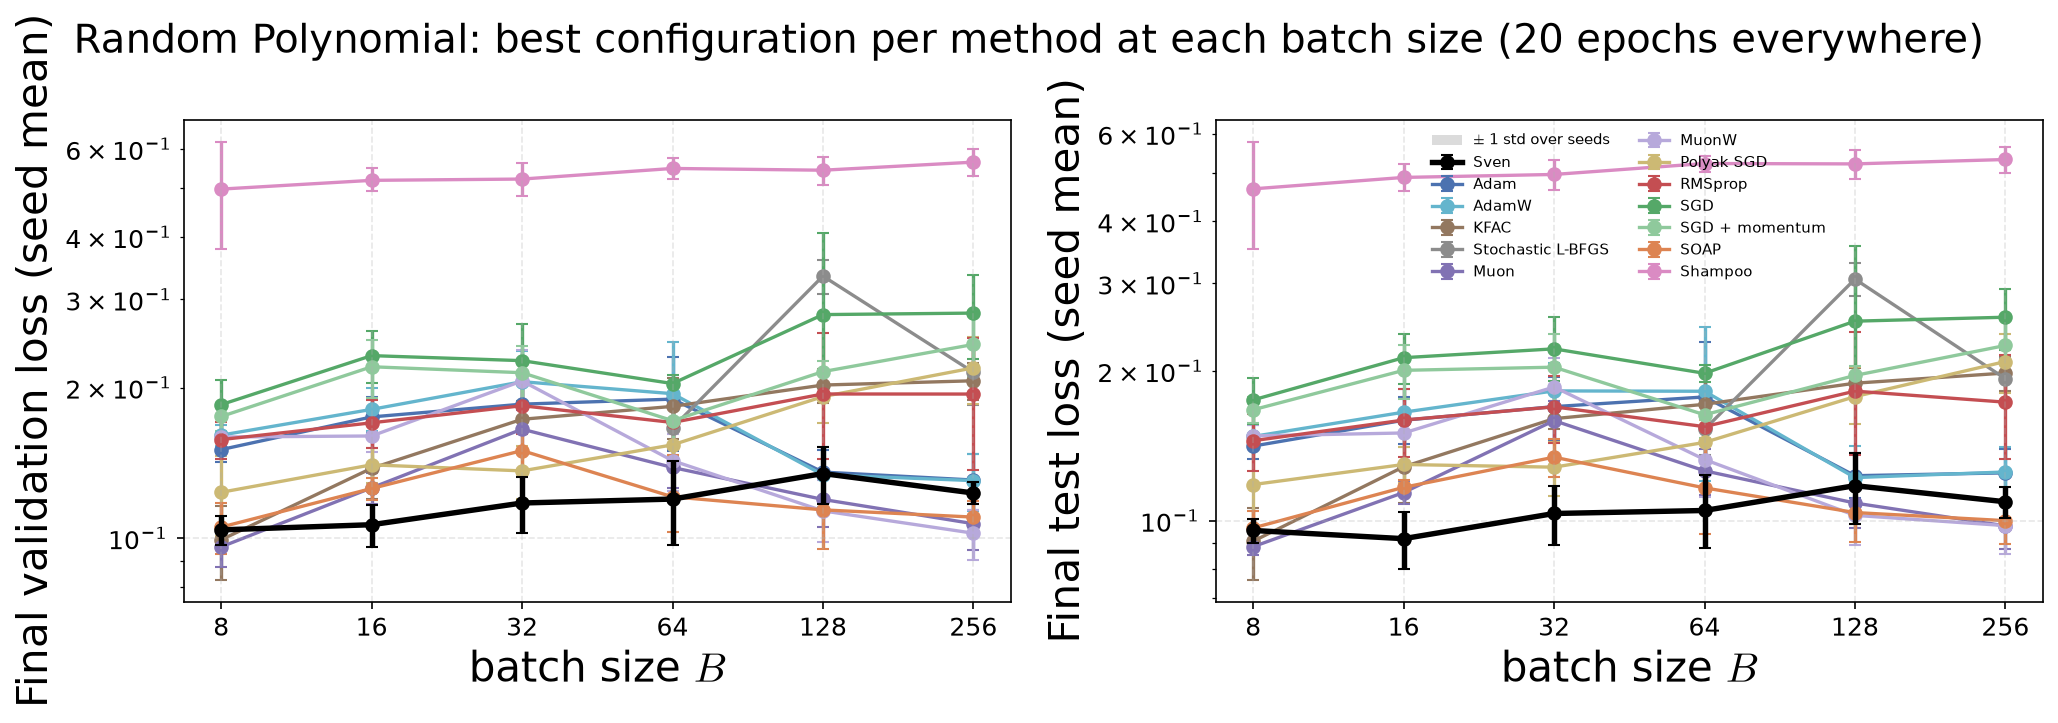

Sven's rank per batch size:
 batch_size  rank_val  n_methods  value                     config counts  rank_test winner_val
          8         3         12 0.1038    lr=0.5, k=8, rtol=1e-05    5/5          3       Muon
         16         1         12 0.1063    lr=0.5, k=16, rtol=0.01    5/5          1       Sven
         32         1         12 0.1175    lr=0.5, k=32, rtol=0.01    5/5          1       Sven
         64         1         13 0.1197    lr=0.5, k=64, rtol=0.01    5/5          1       Sven
        128         5         13 0.1346  lr=0.1, k=128, rtol=0.001    5/5          4      MuonW
        256         4         13 0.1231 lr=0.05, k=256, rtol=0.001    5/5          4      MuonW


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, q in zip(axes, ['final_val_loss', 'final_test_loss']):
    rf.plot_arm(ax, best, 'batch_size', q, logy=True)
    ax.set_xscale('log', base=2)
    ax.set_xticks(Bs)
    ax.set_xticklabels([str(b) for b in Bs])
    ax.set_xlabel('batch size $B$')
    ax.set_ylabel(metric_label(q))
    ax.grid(alpha=0.3, ls='--')
axes[1].legend(fontsize=7, ncol=2)
fig.suptitle(f'{TITLE}: best configuration per method at each batch size '
             '(20 epochs everywhere)')
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'vs_batchsize')
plt.show()

print("Sven's rank per batch size:")
t = ranks_val[ranks_val['method'] == 'Sven'][['batch_size', 'rank', 'n_methods',
                                              'value', 'config', 'counts']]
t = t.merge(ranks_test[ranks_test['method'] == 'Sven'][['batch_size', 'rank']],
            on='batch_size', suffixes=('_val', '_test'))
t['winner_val'] = [best[best['batch_size'] == b].sort_values('final_val_loss')['display']
                   .iloc[0] for b in t['batch_size']]
print(t.to_string(index=False, float_format=lambda v: f'{v:.4g}'))

## 2. Steps or examples?  The budget, made explicit

Equal epochs means equal *examples* and wildly unequal *steps*.  The left panel is the loss
against the number of optimizer steps the 20 epochs bought; the right is against examples
stepped on (constant by construction, up to `drop_last`).  Read together they say that the
batch-size axis of the left figure is a steps axis in disguise.

It would be convenient if "more steps is better" held and the batch-size axis were simply
that axis reversed.  It does not, so the cell **checks** it (`rf.monotonicity_table`) instead
of asserting it: the methods split, and which way a method points is the actual content of
R2 Q1.

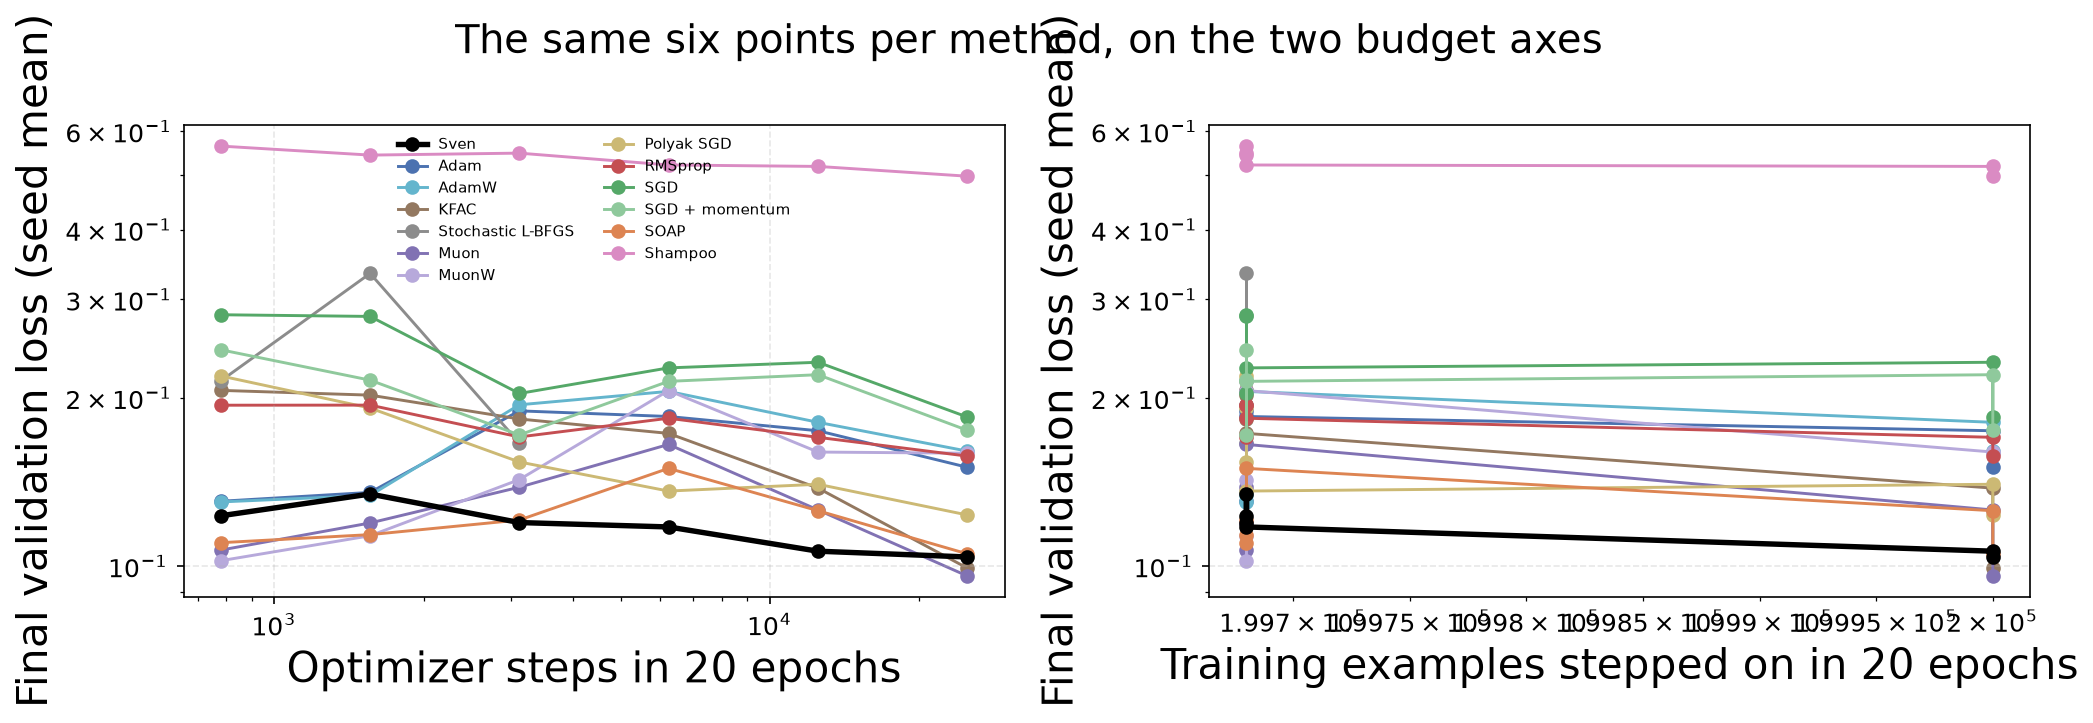

B -> steps/epoch -> steps in 20 epochs -> examples (drop_last=True):
 batch_size  steps_per_epoch  total_steps  examples_per_epoch
          8             1250        25000               10000
         16              625        12500               10000
         32              312         6240                9984
         64              156         3120                9984
        128               78         1560                9984
        256               39          780                9984

IS the steps axis monotone?  (falling = the loss improves as the 20 epochs buy more steps, i.e. as B shrinks)
          display  n  falling  rising  monotone  first    last    best  best_at_B  range_ratio
             Adam  6    False   False     False 0.1306  0.1503  0.1306        256        1.451
            AdamW  6    False   False     False 0.1303  0.1606  0.1303        256        1.577
             KFAC  6     True   False      True 0.2063 0.09921 0.09921          8        2.079
Stocha

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for m in method_order(best['method'].unique()):
    s = best[best['method'] == m].sort_values('batch_size')
    if s.empty:
        continue
    kw = dict(color=method_color(m), lw=2.6 if m == 'Sven' else 1.4, marker='o',
              zorder=3 if m == 'Sven' else 1)
    axes[0].plot(s['total_steps'], s['final_val_loss'], label=method_label(m), **kw)
    axes[1].plot(s['total_examples'], s['final_val_loss'], label=method_label(m), **kw)
for ax, lab in zip(axes, ['Optimizer steps in 20 epochs',
                          'Training examples stepped on in 20 epochs']):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(lab)
    ax.set_ylabel(metric_label('final_val_loss'))
    ax.grid(alpha=0.3, ls='--')
axes[0].legend(fontsize=7, ncol=2)
fig.suptitle('The same six points per method, on the two budget axes')
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'budget_axes')
plt.show()

print('B -> steps/epoch -> steps in 20 epochs -> examples (drop_last=True):')
print(grid[['batch_size', 'steps_per_epoch', 'total_steps', 'examples_per_epoch']]
      .to_string(index=False))
print()

mono = rf.monotonicity_table(best, 'total_steps', 'final_val_loss')
mono['best_at_B'] = [int(best[(best['method'] == m)
                             & np.isclose(best['total_steps'], x)]['batch_size'].iloc[0])
                     for m, x in zip(mono['method'], mono['x_at_best'])]
print('IS the steps axis monotone?  (falling = the loss improves as the 20 epochs buy more '
      'steps, i.e. as B shrinks)')
print(mono[['display', 'n', 'falling', 'rising', 'monotone', 'first', 'last', 'best',
            'best_at_B', 'range_ratio']]
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))
n_mono = int(mono['monotone'].sum())
print(f'\n  -> {n_mono} of {len(mono)} methods are monotone on the steps axis '
      f'({sorted(mono.loc[mono["monotone"], "display"])}).')
print(f'  -> best at the SMALLEST batch (most steps, B={int(best["batch_size"].min())}): '
      f'{sorted(mono.loc[mono["best_at_B"] == int(best["batch_size"].min()), "display"])}')
print(f'  -> best at the LARGEST batch (fewest steps, B={int(best["batch_size"].max())}): '
      f'{sorted(mono.loc[mono["best_at_B"] == int(best["batch_size"].max()), "display"])}')
mid = mono[~mono['best_at_B'].isin([int(best['batch_size'].min()),
                                    int(best['batch_size'].max())])]
print(f'  -> best somewhere in between: '
      + str(sorted(zip(mid['display'], mid['best_at_B']))))

## 3. Sven at $k/B$ fractions — what the update rank really was

$k = B$ is pinned in this scan, so the *requested* $k/B$ is 1 everywhere.  What varies is
how much `rtol` cuts: `rank_eff` is the mean number of singular values kept per step, read
from each run's own `svd_summary`.  The right panel is `rank_eff` $/ B$ — the effective
$k/B$ fraction, which is what a memory or cost claim is actually about.

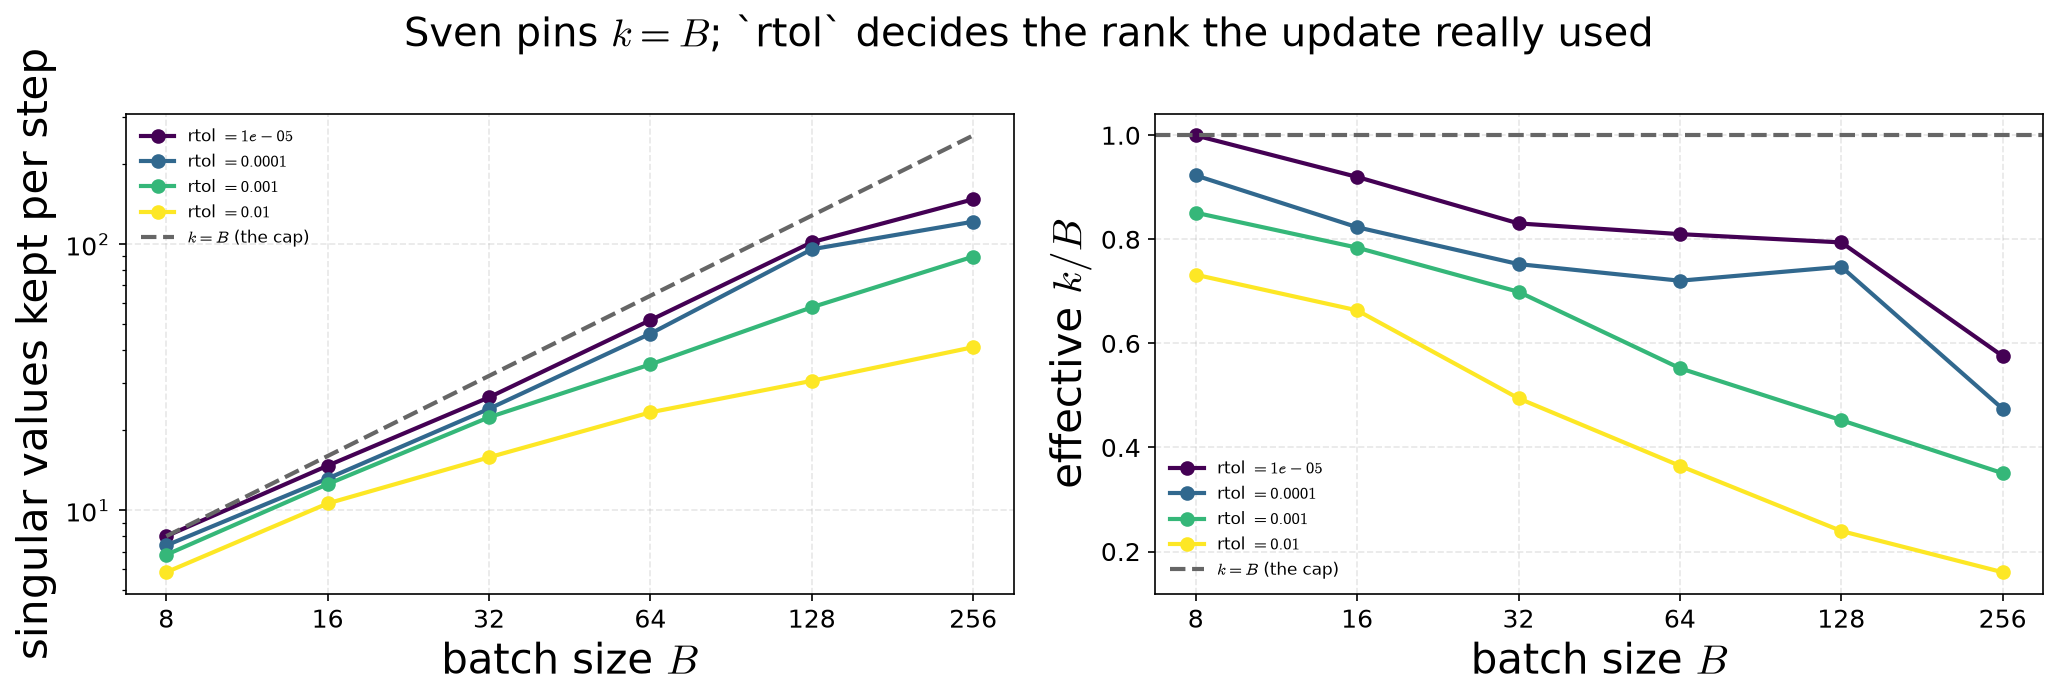

 batch_size   rtol  rank_eff  n  rank_eff_over_B
          8  1e-05     7.997 18           0.9996
          8 0.0001     7.382 20           0.9227
          8  0.001     6.809 20           0.8511
          8   0.01     5.856 20           0.7319
         16  1e-05     14.72 18           0.9198
         16 0.0001     13.17 20           0.8232
         16  0.001     12.54 20            0.784
         16   0.01     10.61 20           0.6634
         32  1e-05     26.58 19           0.8305
         32 0.0001     24.07 20           0.7523
         32  0.001     22.37 20           0.6991
         32   0.01     15.82 20           0.4944
         64  1e-05     51.84 17             0.81
         64 0.0001     46.11 18           0.7204
         64  0.001     35.35 20           0.5523
         64   0.01     23.34 20           0.3647
        128  1e-05     101.6 13            0.794
        128 0.0001     95.64 15           0.7472
        128  0.001     57.91 20           0.4524
        128   0.01  

In [7]:
sv_cfg = (df[df['method'] == 'Sven'].copy())
sv_cfg['rank_eff'] = sv_cfg.apply(rf.effective_rank, axis=1)
ok = sv_cfg[~sv_cfg['diverged'] & ~sv_cfg['failed']]
by_rtol = (ok.groupby(['batch_size', 'rtol'])
           .agg(rank_eff=('rank_eff', 'mean'), n=('run_id', 'size')).reset_index())
by_rtol['rank_eff_over_B'] = by_rtol['rank_eff'] / by_rtol['batch_size']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
cmap = plt.get_cmap('viridis')
rtols = sorted(by_rtol['rtol'].unique())
for i, rt in enumerate(rtols):
    s = by_rtol[by_rtol['rtol'] == rt].sort_values('batch_size')
    c = cmap(i / max(1, len(rtols) - 1))
    axes[0].plot(s['batch_size'], s['rank_eff'], marker='o', color=c,
                 label=f'rtol $= {rt:g}$')
    axes[1].plot(s['batch_size'], s['rank_eff_over_B'], marker='o', color=c,
                 label=f'rtol $= {rt:g}$')
axes[0].plot(Bs, Bs, ls='--', c='0.4', label='$k = B$ (the cap)')
axes[1].axhline(1.0, ls='--', c='0.4', label='$k = B$ (the cap)')
for ax in axes:
    ax.set_xscale('log', base=2)
    ax.set_xticks(Bs)
    ax.set_xticklabels([str(b) for b in Bs])
    ax.set_xlabel('batch size $B$')
    ax.grid(alpha=0.3, ls='--')
    ax.legend(fontsize=8)
axes[0].set_yscale('log')
axes[0].set_ylabel('singular values kept per step')
axes[1].set_ylabel('effective $k / B$')
fig.suptitle('Sven pins $k = B$; `rtol` decides the rank the update really used')
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'effective_rank_vs_batchsize')
plt.show()

print(by_rtol.to_string(index=False, float_format=lambda v: f'{v:.4g}'))
print()
sel = best[best['method'] == 'Sven'][['batch_size', 'config', 'rank_eff']] \
    .sort_values('batch_size').copy()
sel['rank_eff_over_B'] = sel['rank_eff'] / sel['batch_size']
print('the SELECTED Sven configuration per B, and the rank it used:')
print(sel.to_string(index=False, float_format=lambda v: f'{v:.4g}'))

## 4. Robustness across batch size

The wide divergence rule over every run in the arm.  Small batches are where the
second-order baselines fall over, and the effect is monotone: L-BFGS 23/25 at $B = 8$ down
to 2/25 at $B = 256$, K-FAC 25/40 down to 2/40.  Sven runs the **other** way — 2/80 at
$B = 8$ rising to 13/80 at $B = 256$ — and so does RMSprop.

diverged / runs, per method and batch size (wide rule):
batch_size           8      16     32     64     128    256
display                                                    
KFAC               25/40  25/40  21/40  15/40   6/40   2/40
Stochastic L-BFGS  23/25  23/25  20/25  13/25   7/25   2/25
SGD + momentum     14/40  11/40  12/40   9/40   7/40   6/40
SGD                12/40  10/40   8/40   5/40   5/40   5/40
Sven                2/80   2/80   1/80   5/80  12/80  13/80
RMSprop             1/40   1/40   3/40   3/40   8/40   9/40
SOAP                4/40   5/40   4/40   1/40   1/40   1/40
MuonW               2/40   2/40   3/40   0/40   0/40   0/40
Muon                0/40   0/40   0/40   2/40   2/40   1/40
AdamW               0/40   1/40   0/40   0/40   0/40   0/40
Adam                0/40   0/40   0/40   0/40   0/40   0/40
Polyak SGD           0/5    0/5    0/5    0/5    0/5    0/5
Shampoo             0/40   0/40   0/40   0/40   0/40   0/40

  B=   8: 12 methods eligible; no eligible 

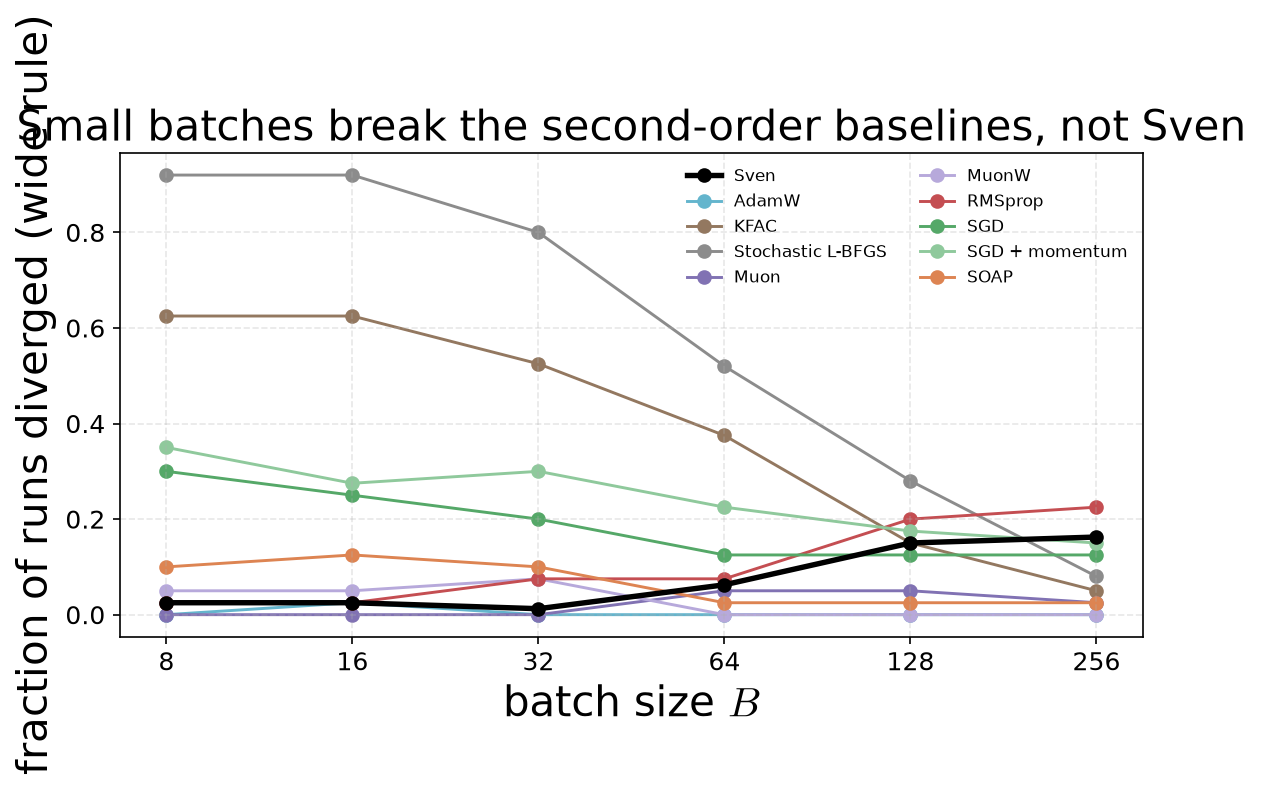

In [8]:
div = rf.divergence_table(df, 'batch_size')
piv = div.pivot_table(index='display', columns='batch_size', values='n_diverged',
                      fill_value=0)
runs = div.pivot_table(index='display', columns='batch_size', values='n_runs',
                       fill_value=0)
show = piv.astype(int).astype(str) + '/' + runs.astype(int).astype(str)
show = show.loc[piv.sum(axis=1).sort_values(ascending=False).index]
print('diverged / runs, per method and batch size (wide rule):')
print(show.to_string())
print()
elig = (best.groupby('batch_size')['method'].apply(lambda s: sorted(set(s))).to_dict())
for b in Bs:
    missing = sorted(set(df['method'].unique()) - set(elig[b]))
    print(f'  B={b:4d}: {len(elig[b])} methods eligible; no eligible config for {missing}')

fig, ax = plt.subplots(figsize=(8, 4.6))
for m in method_order(div['method'].unique()):
    s = div[div['method'] == m].sort_values('batch_size')
    if s['n_diverged'].sum() == 0:
        continue
    ax.plot(s['batch_size'], s['frac'], marker='o', color=method_color(m),
            lw=2.6 if m == 'Sven' else 1.4, label=method_label(m),
            zorder=3 if m == 'Sven' else 1)
ax.set_xscale('log', base=2)
ax.set_xticks(Bs)
ax.set_xticklabels([str(b) for b in Bs])
ax.set_xlabel('batch size $B$')
ax.set_ylabel('fraction of runs diverged (wide rule)')
ax.set_title('Small batches break the second-order baselines, not Sven')
ax.grid(alpha=0.3, ls='--')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'divergence_vs_batchsize')
plt.show()

## 5. What a batch costs: step time and peak memory

`step_s` is each run's recorded mean training time per optimizer step
(`losses.avg_batch_time_train`), `peak_gpu_mem_mb` its peak allocation.  Both are the scan's
own numbers — many processes shared each GPU, so the *level* is an upper bound; the
*shape* in $B$ is the informative part, and it is the part R2's question is about.

**One trap, and the panel that avoids it.**  Reading Sven's step time off the *selected*
configuration of each arm mixes two effects, because the selection jumps between `rtol`
values — and `rtol` alone changes Sven's step time by about a factor of two.  The middle
figure therefore holds `rtol` fixed and lets only $B$ move (`rf.fixed_knob_cost`); that is
the curve a "does the step scale with $B$" claim has to be read off.

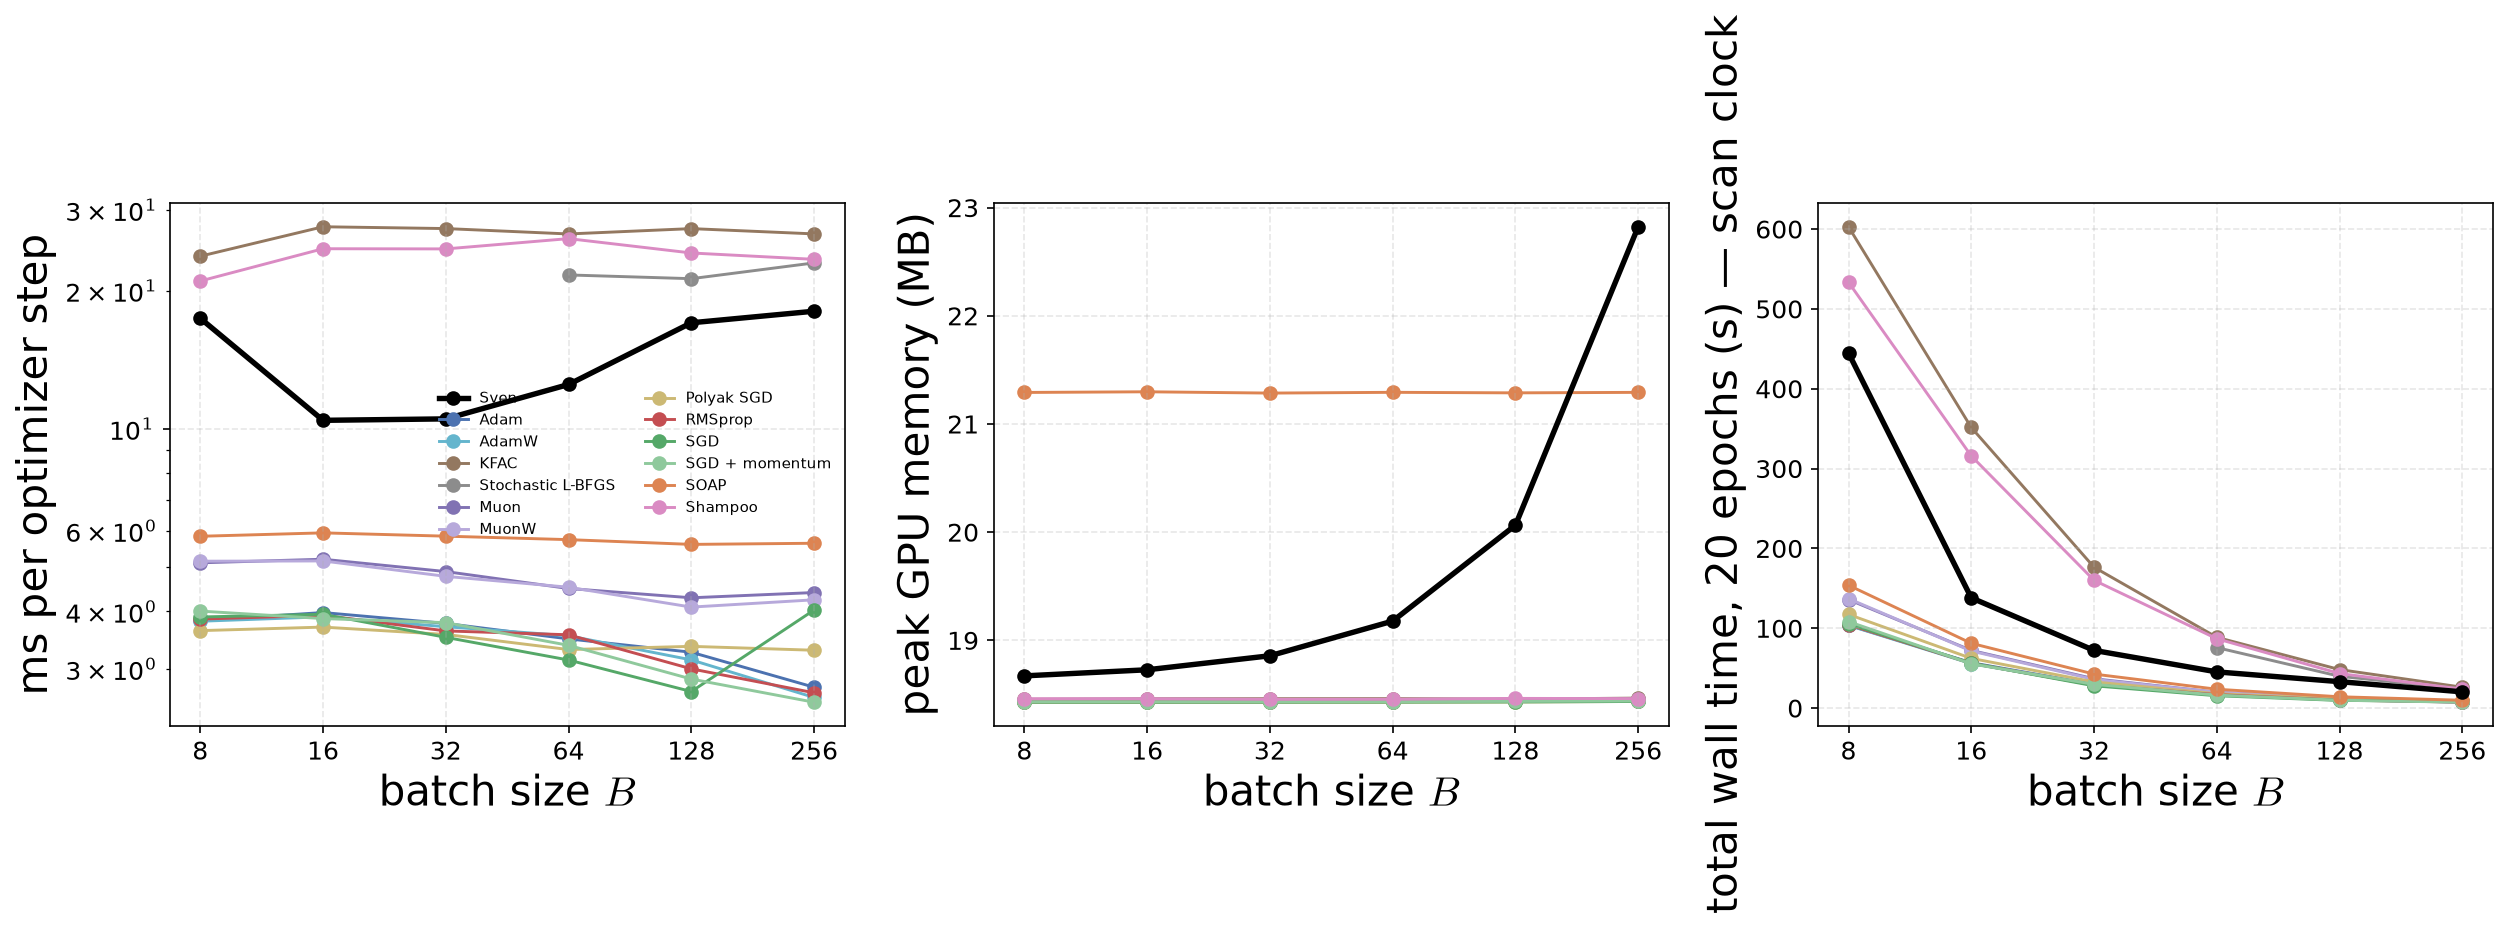

           peak_gpu_mem_mb                                     step_ms                                    
display               Adam MuonW  SOAP Stochastic L-BFGS  Sven    Adam MuonW  SOAP Stochastic L-BFGS  Sven
batch_size                                                                                                
8                    18.44 18.44 21.29               NaN 18.67   3.819 5.143 5.829               NaN 17.41
16                   18.44 18.44  21.3               NaN 18.73   3.975  5.15 5.929               NaN 10.43
32                   18.44 18.44 21.29               NaN 18.86   3.764 4.767 5.832               NaN 10.51
64                   18.44 18.44 21.29             18.45 19.18   3.483 4.513 5.731             21.64 12.49
128                  18.44 18.44 21.29             18.45 20.06   3.257 4.085 5.596             21.23 17.02
256                  18.45 18.44 21.29             18.46 22.82   2.732 4.237 5.628             22.98 18.04


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for m in method_order(best['method'].unique()):
    s = best[best['method'] == m].sort_values('batch_size')
    kw = dict(color=method_color(m), lw=2.6 if m == 'Sven' else 1.4, marker='o',
              label=method_label(m), zorder=3 if m == 'Sven' else 1)
    axes[0].plot(s['batch_size'], s['step_s'] * 1e3, **kw)
    axes[1].plot(s['batch_size'], s['peak_gpu_mem_mb'], **kw)
    axes[2].plot(s['batch_size'], s['total_time'], **kw)
for ax, lab in zip(axes, ['ms per optimizer step', 'peak GPU memory (MB)',
                          'total wall time, 20 epochs (s) — scan clock']):
    ax.set_xscale('log', base=2)
    ax.set_xticks(Bs)
    ax.set_xticklabels([str(b) for b in Bs])
    ax.set_xlabel('batch size $B$')
    ax.set_ylabel(lab)
    ax.grid(alpha=0.3, ls='--')
axes[0].set_yscale('log')
axes[0].legend(fontsize=7, ncol=2)
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'cost_vs_batchsize')
plt.show()

cost = best[best['method'].isin(['Sven', 'Adam', 'MuonW', 'SOAP', 'LBFGS'])][
    ['batch_size', 'display', 'step_s', 'peak_gpu_mem_mb', 'total_time']]
print((cost.assign(step_ms=lambda t: t['step_s'] * 1e3)
       .drop(columns='step_s')
       .pivot_table(index='batch_size', columns='display',
                    values=['step_ms', 'peak_gpu_mem_mb']))
      .to_string(float_format=lambda v: f'{v:.4g}'))

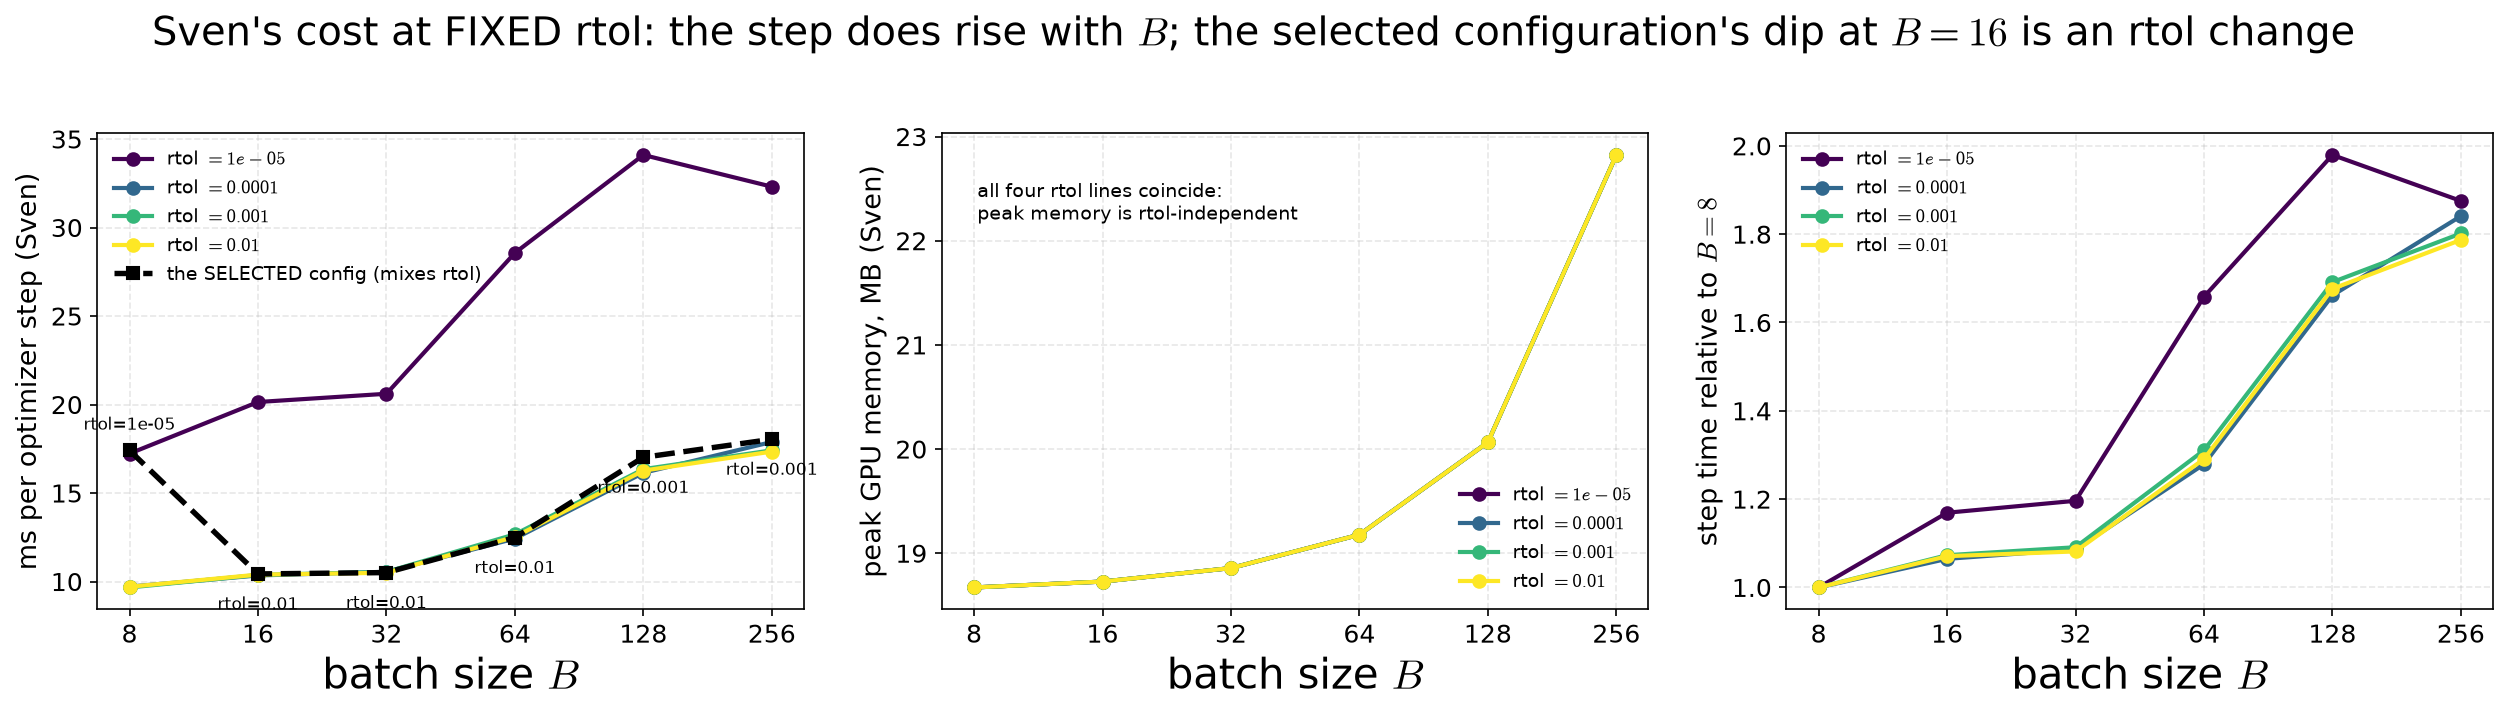

Sven ms per optimizer step, rows = rtol (fixed), columns = B:
batch_size   8     16    32    64    128   256
rtol                                          
0.00001    17.23 20.14 20.61 28.57 34.10 32.31
0.00010     9.72 10.34 10.55 12.43 16.14 17.89
0.00100     9.67 10.37 10.55 12.67 16.35 17.41
0.01000     9.70 10.39 10.50 12.53 16.27 17.34

Sven peak GPU memory (MB), rows = rtol, columns = B:
batch_size   8     16    32    64    128   256
rtol                                          
0.00001    18.67 18.73 18.86 19.18 20.06 22.82
0.00010    18.67 18.73 18.86 19.18 20.06 22.82
0.00100    18.67 18.73 18.86 19.18 20.06 22.82
0.01000    18.67 18.73 18.86 19.18 20.06 22.82

  rtol=1e-05    step time B=8 -> 256: 17.23 -> 32.31 ms (1.88x), monotone in B: False
  rtol=0.0001   step time B=8 -> 256: 9.72 -> 17.89 ms (1.84x), monotone in B: True
  rtol=0.001    step time B=8 -> 256: 9.67 -> 17.41 ms (1.80x), monotone in B: True
  rtol=0.01     step time B=8 -> 256: 9.70 -> 17.34 ms (1.79x), m

In [10]:
# The confound: the per-arm SELECTED config changes rtol, and rtol alone roughly doubles
# Sven's step.  Hold rtol fixed and only B moves.
step_rtol = rf.fixed_knob_cost(df, 'batch_size', 'rtol', 'avg_batch_time_train', scale=1e3)
mem_rtol = rf.fixed_knob_cost(df, 'batch_size', 'rtol', 'peak_gpu_mem_mb')
piv_step = step_rtol.pivot(index='rtol', columns='batch_size', values='value')
piv_mem = mem_rtol.pivot(index='rtol', columns='batch_size', values='value')

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
cmap = plt.get_cmap('viridis')
rts = sorted(step_rtol['rtol'].unique())
for i, rt in enumerate(rts):
    c = cmap(i / max(1, len(rts) - 1))
    s = step_rtol[step_rtol['rtol'] == rt].sort_values('batch_size')
    axes[0].plot(s['batch_size'], s['value'], marker='o', color=c, lw=2,
                 label=f'rtol $= {rt:g}$')
    m = mem_rtol[mem_rtol['rtol'] == rt].sort_values('batch_size')
    axes[1].plot(m['batch_size'], m['value'], marker='o', color=c, lw=2,
                 label=f'rtol $= {rt:g}$')
sel = best[best['method'] == 'Sven'].sort_values('batch_size')
axes[0].plot(sel['batch_size'], sel['step_s'] * 1e3, marker='s', ls='--', lw=2.6,
             color='k', label='the SELECTED config (mixes rtol)')
for _, r in sel.iterrows():
    axes[0].annotate(f'rtol={r["rtol"]:g}', (r['batch_size'], r['step_s'] * 1e3),
                     textcoords='offset points', fontsize=8, ha='center',
                     xytext=(0, 10) if r['batch_size'] == Bs[0] else (0, -17))
axes[1].annotate('all four rtol lines coincide:\npeak memory is rtol-independent',
                 (0.05, 0.9), xycoords='axes fraction', fontsize=9, va='top')
ratio = (piv_step / piv_step.loc[piv_step.index.min()]).T if len(piv_step) else None
for i, rt in enumerate(rts):
    s = step_rtol[step_rtol['rtol'] == rt].sort_values('batch_size')
    axes[2].plot(s['batch_size'], s['value'] / s['value'].iloc[0], marker='o',
                 color=cmap(i / max(1, len(rts) - 1)), lw=2, label=f'rtol $= {rt:g}$')
for ax, lab in zip(axes, ['ms per optimizer step (Sven)', 'peak GPU memory, MB (Sven)',
                          'step time relative to $B = 8$']):
    ax.set_xscale('log', base=2)
    ax.set_xticks(Bs)
    ax.set_xticklabels([str(b) for b in Bs])
    ax.set_xlabel('batch size $B$')
    ax.set_ylabel(lab, fontsize=13)
    ax.grid(alpha=0.3, ls='--')
    ax.legend(fontsize=9)
fig.suptitle("Sven's cost at FIXED rtol: the step does rise with $B$; the selected "
             "configuration's dip at $B=16$ is an rtol change", y=1.0)
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'sven_cost_fixed_rtol')
plt.show()

print('Sven ms per optimizer step, rows = rtol (fixed), columns = B:')
print(piv_step.to_string(float_format=lambda v: f'{v:.2f}'))
print()
print('Sven peak GPU memory (MB), rows = rtol, columns = B:')
print(piv_mem.to_string(float_format=lambda v: f'{v:.2f}'))
print()
for rt in rts:
    row = piv_step.loc[rt]
    print(f'  rtol={rt:<8g} step time B={int(row.index.min())} -> '
          f'{int(row.index.max())}: {row.iloc[0]:.2f} -> {row.iloc[-1]:.2f} ms '
          f'({row.iloc[-1] / row.iloc[0]:.2f}x), monotone in B: '
          f'{bool(np.all(np.diff(row.to_numpy()) >= 0))}')
lo, hi = min(rts), max(rts)
print(f'\n  and at FIXED B, rtol={lo:g} costs '
      f'{(piv_step.loc[lo] / piv_step.loc[1e-3]).min():.2f}-'
      f'{(piv_step.loc[lo] / piv_step.loc[1e-3]).max():.2f}x the rtol=1e-3 step.')
print(f'  the selected configs use rtol = '
      f'{dict(zip(sel["batch_size"].astype(int), sel["rtol"]))} — which is why the '
      'per-arm curve is not monotone.')

## 6. Edge optima

An optimum on the lowest or highest value of the grid it was searched on means the grid,
not the method, may be what is being measured.  That matters most where the edge coincides
with a **win**, so the cell cross-tabulates the edges against Sven's rank in the same arm.

In [11]:
edges = rf.edge_optima(df, best, 'batch_size')
coin = edges.iloc[:0]
if edges.empty:
    print('no selected configuration sits on a grid edge.')
else:
    print(edges.to_string(index=False, float_format=lambda v: f'{v:.4g}'))
    print()
    print(edges.groupby(['display', 'knob', 'side']).size().rename('n_arms').to_string())
    print()
    rk = ranks_val.set_index(['method', 'batch_size'])['rank']
    e2 = edges.copy()
    e2['sven_rank_in_arm'] = [int(rk.get(('Sven', b), np.nan)) for b in e2['batch_size']]
    e2['own_rank_in_arm'] = [int(rk.get((m, b), np.nan)) if not pd.isna(rk.get((m, b)))
                             else -1 for m, b in zip(e2['method'], e2['batch_size'])]
    print('every edge optimum beside the rank it produced:')
    print(e2[['batch_size', 'display', 'knob', 'value', 'side', 'grid',
              'own_rank_in_arm', 'sven_rank_in_arm']]
          .to_string(index=False, float_format=lambda v: f'{v:.4g}'))
    coin = e2[(e2['method'] == 'Sven') & (e2['own_rank_in_arm'] == 1)]
    if len(coin):
        print(f'\n  ** {len(coin)} of Sven\'s edge optima sit in an arm it RANKS 1st in: '
              + ', '.join(f'B={int(r["batch_size"])} ({r["knob"]}={r["value"]:g}, '
                          f'{r["side"]} edge of {r["grid"]})'
                          for _, r in coin.iterrows()))
        print('     i.e. in those arms the rtol grid, not the method, may be what is '
              'measured — the optimum wants a value the scan never ran.')

 batch_size method           display knob  value side  n_values            grid
          8   KFAC              KFAC   lr  1e-05  low         8    [1e-05 .. 1]
         16   KFAC              KFAC   lr  1e-05  low         8    [1e-05 .. 1]
         32   KFAC              KFAC   lr  1e-05  low         8    [1e-05 .. 1]
        128  LBFGS Stochastic L-BFGS   lr    0.1  low         5      [0.1 .. 4]
        256   Sven              Sven   lr   0.05  low         4     [0.05 .. 1]
          8   Sven              Sven rtol  1e-05  low         4 [1e-05 .. 0.01]
         16   Sven              Sven rtol   0.01 high         4 [1e-05 .. 0.01]
         32   Sven              Sven rtol   0.01 high         4 [1e-05 .. 0.01]
         64   Sven              Sven rtol   0.01 high         4 [1e-05 .. 0.01]

display            knob  side
KFAC               lr    low     3
Stochastic L-BFGS  lr    low     1
Sven               lr    low     1
                   rtol  high    3
                         low 

## 7. Computed summary

In [12]:
lines = []
lines.append(f'BATCH-SIZE SENSITIVITY ({TITLE}) — computed summary')
lines.append('=' * 78)
lines.append(f'{census["n_records"]} records, {census["n_missing"]} missing, '
             f'{census["n_diverged"]} diverged (wide), {census["n_methods"]} methods, '
             f'{len(census["seeds"])} seeds, 20 epochs, N_train = '
             f'{int(df["n_train"].dropna().iloc[0])}')
r = ranks_val[ranks_val['method'] == 'Sven'].sort_values('batch_size')
lines.append('  B          : ' + '  '.join(f'{int(b):6d}' for b in r['batch_size']))
lines.append('  Sven rank  : ' + '  '.join(f'{int(x):2d}/{int(n):<3d}' for x, n in
                                           zip(r['rank'], r['n_methods'])))
lines.append('  Sven val   : ' + '  '.join(f'{v:6.4f}' for v in r['value']))
lines.append('  winner     : ' + '  '.join(
    f'{best[best["batch_size"] == b].sort_values("final_val_loss")["display"].iloc[0][:6]:>6s}'
    for b in r['batch_size']))
lines.append('  steps/20ep : ' + '  '.join(f'{int(s):6d}' for s in grid['total_steps']))
sv_sel = best[best['method'] == 'Sven'].sort_values('batch_size')
lines.append('  rank_eff   : ' + '  '.join(f'{v:6.1f}' for v in sv_sel['rank_eff']))
lines.append('  rank_eff/B : ' + '  '.join(f'{v:6.2f}' for v in
                                           sv_sel['rank_eff'] / sv_sel['batch_size']))
lines.append('  Sven ms/st : ' + '  '.join(f'{v*1e3:6.1f}' for v in sv_sel['step_s']))
ad = best[best['method'] == 'Adam'].sort_values('batch_size')
lines.append('  Adam ms/st : ' + '  '.join(f'{v*1e3:6.1f}' for v in ad['step_s']))
lines.append('  Sven MB    : ' + '  '.join(f'{v:6.1f}' for v in sv_sel['peak_gpu_mem_mb']))
lines.append('  Adam MB    : ' + '  '.join(f'{v:6.1f}' for v in ad['peak_gpu_mem_mb']))
lines.append('')
best_B = r.sort_values('rank').iloc[0]
lines.append(f'  Sven is best-ranked at B = {int(best_B["batch_size"])} '
             f'(rank {int(best_B["rank"])}/{int(best_B["n_methods"])}) and worst-ranked at '
             f'B = {int(r.sort_values("rank").iloc[-1]["batch_size"])} '
             f'(rank {int(r.sort_values("rank").iloc[-1]["rank"])})')
rng = r['value'].max() / r['value'].min()
lines.append(f'  Sven validation loss varies by {rng:.2f}x over the 32x batch-size range; '
             + ', '.join(
                 f'{method_label(m)} {best[best["method"] == m]["final_val_loss"].max() / best[best["method"] == m]["final_val_loss"].min():.2f}x'
                 for m in ('Adam', 'MuonW', 'SGD') if (best['method'] == m).any()))
lb_ok = sorted(best[best['method'] == 'LBFGS']['batch_size'].tolist())
lines.append(f'  L-BFGS (max_iter=3, history=2, O5) has an eligible configuration only at '
             f'B = {lb_ok}')
n_edge = 0 if edges.empty else len(edges)
lines.append(f'  edge optima: {n_edge} '
             f'({0 if edges.empty else int((edges["method"] == "Sven").sum())} Sven); '
             f'{len(coin)} of Sven\'s in an arm it ranks 1st in')
lines.append(f'  monotone on the steps axis: {n_mono} of {len(mono)} methods '
             f'({sorted(mono.loc[mono["monotone"], "display"])})')
for rt in rts:
    row = piv_step.loc[rt]
    lines.append(f'  Sven ms/step at FIXED rtol={rt:<7g}: '
                 + '  '.join(f'{v:6.2f}' for v in row) +
                 f'   ({row.iloc[-1] / row.iloc[0]:.2f}x over B = '
                 f'{int(row.index.min())}..{int(row.index.max())})')
sig = gaps[(gaps['rank'] == 1) & (gaps['rival_rank'] > 1)]
lines.append(f'  of the {len(sig)} rank-1 gaps, {int(sig["significant"].sum())} clear the '
             f'paired seed noise at 95%: '
             f'{sorted(set(sig.loc[sig["significant"], "batch_size"].astype(int)))}')
print('\n'.join(lines))

BATCH-SIZE SENSITIVITY (Random Polynomial) — computed summary
3060 records, 0 missing, 375 diverged (wide), 13 methods, 5 seeds, 20 epochs, N_train = 10000
  B          :      8      16      32      64     128     256
  Sven rank  :  3/12    1/12    1/12    1/13    5/13    4/13 
  Sven val   : 0.1038  0.1063  0.1175  0.1197  0.1346  0.1231
  winner     :   Muon    Sven    Sven    Sven   MuonW   MuonW
  steps/20ep :  25000   12500    6240    3120    1560     780
  rank_eff   :    8.0    10.6    17.2    27.3    82.3   126.0
  rank_eff/B :   1.00    0.66    0.54    0.43    0.64    0.49
  Sven ms/st :   17.4    10.4    10.5    12.5    17.0    18.0
  Adam ms/st :    3.8     4.0     3.8     3.5     3.3     2.7
  Sven MB    :   18.7    18.7    18.9    19.2    20.1    22.8
  Adam MB    :   18.4    18.4    18.4    18.4    18.4    18.4

  Sven is best-ranked at B = 16 (rank 1/12) and worst-ranked at B = 128 (rank 5)
  Sven validation loss varies by 1.30x over the 32x batch-size range; Adam 1.45x

## 8. Conclusion

**Sven is batch-size sensitive, and its good region is the middle of the range.**

* Sven ranks **1st of 12–13** at $B = 16, 32, 64$, **3rd** at $B = 8$ and **5th / 4th** at
  $B = 128 / 256$, where MuonW, Muon and SOAP take over.  Its own validation loss varies by
  only ~1.3× across the 32× batch-size range — less than SGD's — so the rank changes are
  mostly the baselines improving with larger batches, not Sven degrading.
* **Only one of the three wins is bigger than the seeds.**  Paired by the 5 model seeds,
  $B = 16$ is clear (Sven − SOAP $= -0.0193$, $t = -4.34$; − Muon $t = -5.33$), but $B = 64$
  is a tie against both its neighbours (Sven − SOAP $= -0.0012$, $t = -0.07$; − Muon
  $t = -1.72$), and at $B = 32$ the *nearest* rival is inside the noise (Sven − PolyakSGD
  $= -0.019$, $t = -1.59$) while the next one is not (− SOAP $t = -3.38$).  The **losses** at
  large $B$ are real: Sven − SOAP $= +0.013$ ($t = +3.32$) at $B = 256$.  Quote the shape of
  the curve, not the individual placements.
* The mechanism is visible in §3: $k = B$ is pinned, so the update rank is capped by the
  batch, and `rtol` cuts it further.  At the selected configuration the effective rank is
  8.0 of 8 at $B = 8$ but only ~126 of 256 at $B = 256$ — Sven at large $B$ is already
  running at an effective $k/B \approx 0.5$ without being asked to, which is why growing $B$
  buys it much less than it buys a first-order method.
* **Equal epochs is not an equal step budget** (§2): 25,000 steps at $B = 8$ against 780 at
  $B = 256$, at the same number of examples.  But the steps axis is **not** simply the
  batch-size axis reversed, and the computed check in §2 says so: **1 of the 13 methods is
  monotone in steps** (K-FAC, which improves all the way down to $B = 8$).  The field splits
  three ways — Sven, SOAP, Muon, PolyakSGD, RMSprop, SGD, Shampoo and K-FAC are best at the
  **smallest** batch (25,000 steps); **Adam, AdamW and MuonW are best at the largest**
  ($B = 256$, 780 steps); L-BFGS and SGD+momentum peak in the middle at $B = 64$.  So
  "bigger batches are better" and "more steps are better" are both wrong as general
  statements on this scan, and a loss-vs-$B$ curve cannot be re-read as a budget curve.
  Sven's own trajectory is the first kind — 0.1231 (780 steps), 0.1346, 0.1197, 0.1175,
  0.1063, **0.1038** (25,000 steps) — non-monotone, but better with more steps overall.
* **Cost: the step does scale with $B$; the "non-monotone" reading was a confound.**  Read
  off the per-arm *selected* configuration, Sven's step looks non-monotone (17.4 ms at
  $B = 8$, 10.4 ms at $B = 16$, 18.0 ms at $B = 256$) — but the $B = 8$ arm selects
  `rtol` $=10^{-5}$ and every other arm does not, and `rtol` $=10^{-5}$ costs **1.8–2.3×**
  the step of any other `rtol` at the same $B$.  At **fixed** `rtol` (§5, middle figure) the
  step rises with $B$, monotonically for `rtol` $\ge 10^{-4}$: `rtol` $=10^{-3}$ gives 9.67,
  10.37, 10.55, 12.67, 16.35, **17.41 ms** for $B = 8 \ldots 256$ (1.80×), `rtol` $=10^{-2}$
  9.70 → 17.34 (1.79×) and `rtol` $=10^{-5}$ 17.23 → 32.31 (1.88×, with a dip at the last
  point).  So there are two separate costs — the batch, worth ~1.8×
  over a 32× range, and the tolerance, worth ~2× at every $B$ — and neither is "the step is
  dominated by capture and the $B \times B$ eigh, not by $B$".  Adam is at 2.7–4.0 ms and
  L-BFGS 21–23 ms throughout.  Since the step count falls as $1/B$, larger batches still
  make an epoch of Sven cheaper while making it relatively weaker per step.  Peak memory is
  `rtol`-independent and monotone — 18.7 MB at $B = 8$ to 22.8 MB at $B = 256$, against a
  flat 18.4 MB for every first-order baseline (SOAP sits at 21.3 MB).
* **The scan has no $k/B < 1$ arm.**  R2's question about $k/B$ fractions is answered here
  only through the `rtol`-induced rank; the explicit $k/B \in \{0.25, 0.5, 1\}$ sweep lives
  in the headline and over-parameterisation scans.
* **The two methods swap failure modes with $B$.**  L-BFGS at the O5 shape has no eligible
  configuration at all below $B = 64$ (23 of 25 runs diverge at $B = 8$) and K-FAC loses 25
  of 40, while Sven's wide divergence rate *rises* with the batch, 2/80 at $B = 8$ to 13/80
  at $B = 256$ — the same rtol-grid-bottom pattern as everywhere else, now amplified because
  a larger Gram matrix has more nearly-zero singular values to divide by.  Neither method's
  robustness can be quoted at one batch size.
* **Edge optima, and where they land (§6).**  9 selected configurations sit on a grid edge,
  5 of them Sven's — and three of those five are `rtol` $= 10^{-2}$, the **top** of Sven's
  rtol grid, in exactly the three arms Sven ranks 1st in ($B = 16, 32, 64$).  The optimum
  there wants a looser tolerance than the scan ever ran, so in the notebook's three headline
  arms it is partly the rtol grid, not the method, that is being measured; the CIFAR-CE
  extension round exists for the same reason.  The other edges: Sven at $\eta = 0.05$ (grid
  bottom) at $B = 256$ and at `rtol` $= 10^{-5}$ (grid bottom) at $B = 8$ — the arm whose
  step time the bullet above had to disentangle — K-FAC at $\eta = 10^{-5}$ (grid bottom) in
  three arms, and L-BFGS at $\eta = 0.1$ (grid bottom) at $B = 128$.